In [11]:
library(Seurat)

In [12]:
sc.T1 <- readRDS('/syn1/liangzhen/jinhua_jilab_project/result/scRNA/cellranger/T1/sc.all.merge.rds')
sc.T1@meta.data$time <- 'T1'
sc.T1@meta.data$orig.ident <- substr(rownames(sc.T1@meta.data),1,8)

sc.T2 <- readRDS('/syn1/liangzhen/jinhua_jilab_project/result/scRNA/cellranger/T2/sc.all.merge.rds')
sc.T2@meta.data$time <- 'T2'
sc.T2@meta.data$orig.ident <- substr(rownames(sc.T2@meta.data),1,8)

sc.T3 <- readRDS('/syn1/liangzhen/jinhua_jilab_project/result/scRNA/cellranger/T3/sc.all.merge.rds')
sc.T3@meta.data$time <- 'T3'
sc.T3@meta.data$orig.ident <- substr(rownames(sc.T3@meta.data),1,8)

In [13]:
sc.all.merge <- merge(sc.T1,y = list(sc.T2,sc.T3), add.cell.ids = c('T1','T2','T3'), project = "EP_mouse")

In [14]:
sc.all.merge <- JoinLayers(sc.all.merge)

In [15]:
sc.all.merge

An object of class Seurat 
32285 features across 92018 samples within 1 assay 
Active assay: RNA (32285 features, 2000 variable features)
 3 layers present: scale.data, data, counts

In [16]:
sc.all.merge <- NormalizeData(sc.all.merge)

Normalizing layer: counts



In [8]:
library(gprofiler2)
s.genes = gorth(cc.genes.updated.2019$s.genes, source_organism = "hsapiens", target_organism = "mmusculus")$ortholog_name
g2m.genes = gorth(cc.genes.updated.2019$g2m.genes, source_organism = "hsapiens", target_organism = "mmusculus")$ortholog_name

ERROR: Error in function (type, msg, asError = TRUE) : Failed to connect to biit.cs.ut.ee port 80 after 255124 ms: Couldn't connect to server


In [17]:
s.genes = c('Mcm5','Pcna','Tyms','Fen1','Mcm7','Mcm4','Rrm1','Ung','Gins2','Mcm6','Cdca7','Dtl','Prim1','Uhrf1','Cenpu','Hells','Rfc2','Polr1b','Nasp','Rad51ap1','Gmnn','Wdr76','Slbp','Ccne2','Ubr7','Msh2','Rad51','Rrm2','Cdc45','Cdc6','Exo1','Tipin','Dscc1','Blm','Casp8ap2','Usp1','Clspn','Pola1','Chaf1b','Mrpl36','E2f8')
g2m.genes = c('Hmgb2','Cdk1','Nusap1','Ube2c','Birc5','Tpx2','Top2a','Ndc80','Cks2','Nuf2','Cks1b','Mki67','Tmpo','Cenpf','Tacc3','Pimreg','Smc4','Ccnb2','Ckap2l','Ckap2','Aurkb','Bub1','Kif11','Anp32e','Tubb4b','Gtse1','Kif20b','Hjurp','Cdca3','Jpt1','Cdc20','Ttk','Cdc25c','Kif2c','Rangap1','Ncapd2','Dlgap5','Cdca2','Cdca8','Ect2','Kif23','Hmmr','Aurka','Psrc1','Anln','Lbr','Ckap5','Cenpe','Ctcf','Nek2','G2e3','Gas2l3','Cbx5','Cenpa')

In [18]:
sc.all.merge <- CellCycleScoring(
  object = sc.all.merge,
  s.features = s.genes,
  g2m.features = g2m.genes,
  set.ident = TRUE
)

In [19]:
sc.all.merge[["RNA"]] <- split(sc.all.merge[["RNA"]], f = sc.all.merge$orig.ident)

Splitting ‘counts’, ‘data’ layers. Not splitting ‘scale.data’. If you would like to split other layers, set in `layers` argument.



In [20]:
sc.all.merge <- FindVariableFeatures(sc.all.merge, selection.method = "vst", nfeatures = 2000)

sc.all.merge <- ScaleData(
  sc.all.merge,
  vars.to.regress = c("S.Score", "G2M.Score"), features = rownames(sc.all.merge)
)
#all.genes <- rownames(sc.all.merge)
#sc.all.merge <- ScaleData(sc.all.merge, features = all.genes)
sc.all.merge <- RunPCA(sc.all.merge, features = VariableFeatures(object = sc.all.merge))#features = VariableFeatures(object = sc.all.merge)features = c(s.genes, g2m.genes)


Finding variable features for layer counts.T1_a3026

Finding variable features for layer counts.T1_a3028

Finding variable features for layer counts.T1_a3030

Finding variable features for layer counts.T2_a3026

Finding variable features for layer counts.T2_a3028

Finding variable features for layer counts.T2_a3030

Finding variable features for layer counts.T3_a3026

Finding variable features for layer counts.T3_a3028

Finding variable features for layer counts.T3_a3030

Regressing out S.Score, G2M.Score

Centering and scaling data matrix

PC_ 1 
Positive:  Zfpm2, Cdk14, Cdk6, Zbtb20, Maml3, Maml2, Pcdh7, Kirrel3, Mast4, Pde4d 
	   Diaph2, Lpp, Airn, Camk2d, Gpc6, Mecom, Nbea, Ldlrad4, Pbx1, 4930467D21Rik 
	   Hmga2, Apbb2, Ralgapa2, Celf2, Atxn1, Ltbp1, Nfkb1, Runx1, Ano6, Nav1 
Negative:  Ftl1, 2410006H16Rik, Gas5, 1110038B12Rik, Lgals3, Snhg12, Snhg1, Pgk1, Ddit3, Ero1l 
	   Zfas1, Snhg20, Rps15, Snhg16, Higd1a, 5430416N02Rik, Atf4, Nupr1, Bnip3, Rps2 
	   Mt1, Bsg, Hist1h4i, Snhg5

In [22]:
sc.all.merge@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.2,seurat_clusters,pANN_0.25_0.12_592,Doublet_or_Singlet,pANN_0.25_0.21_600,pANN_0.25_0.19_742,⋯,pANN_0.25_0.28_666,pANN_0.25_0.17_630,pANN_0.25_0.29_759,pANN_0.25_0.28_612,pANN_0.25_0.14_771,pANN_0.25_0.07_798,S.Score,G2M.Score,Phase,old.ident
,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
T1_T1_a3026_AAACCCAAGACTAGAT-1,T1_a3026,23101,4348,5.6534349,1,1,0.31401210,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,0.012065095,0.61452212,G2M,1
T1_T1_a3026_AAACCCACATGAGATA-1,T1_a3026,13159,3546,2.0290296,0,0,0.35635081,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,-0.053119614,-0.16313446,G1,0
T1_T1_a3026_AAACCCAGTCGCTGCA-1,T1_a3026,15441,3362,5.9840684,0,0,0.25604839,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,-0.082719878,-0.19668519,G1,0
T1_T1_a3026_AAACCCAGTCTCGCGA-1,T1_a3026,87500,7440,4.8742857,0,0,0.45211694,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,-0.097319383,-0.14913332,G1,0
T1_T1_a3026_AAACCCATCACGGGAA-1,T1_a3026,22915,3939,4.2330351,0,0,0.25000000,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,-0.118859736,-0.09487525,G1,0
T1_T1_a3026_AAACCCATCGCTTACC-1,T1_a3026,16459,4443,1.6951212,0,0,0.35584677,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,-0.087726736,-0.17053891,G1,0
T1_T1_a3026_AAACGAAAGATGAAGG-1,T1_a3026,41955,5372,2.9293290,0,0,0.34274194,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,0.034419357,-0.06208771,S,0
T1_T1_a3026_AAACGAAAGATGGCGT-1,T1_a3026,23998,4543,3.2752729,1,1,0.32409274,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,0.322603105,0.12259944,S,1
T1_T1_a3026_AAACGAAAGGATACAT-1,T1_a3026,19233,3932,3.7227682,0,0,0.35181452,Singlet,NA,NA,⋯,NA,NA,NA,NA,NA,NA,-0.050941861,-0.13268983,G1,0


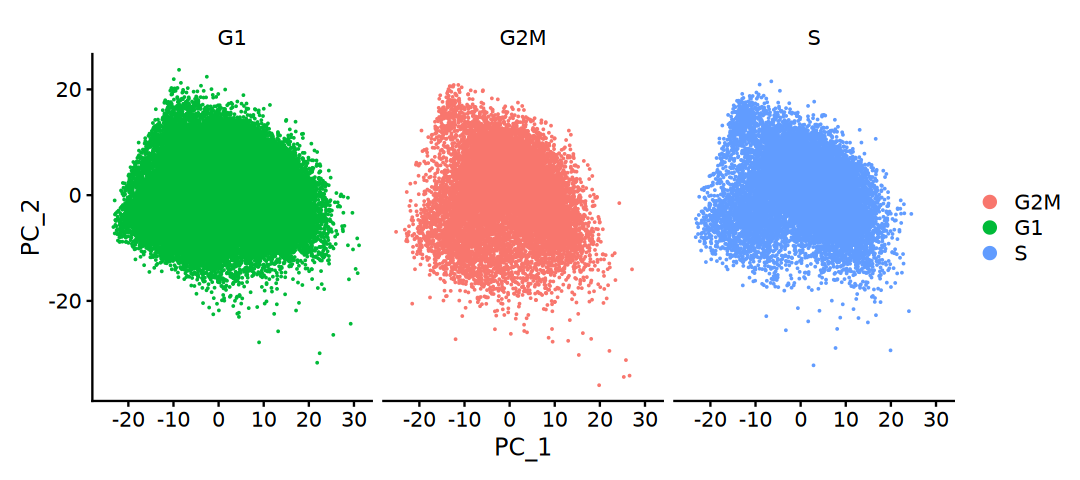

In [23]:
options(repr.plot.width=9, repr.plot.height=4)
DimPlot(sc.all.merge,split.by = 'Phase')

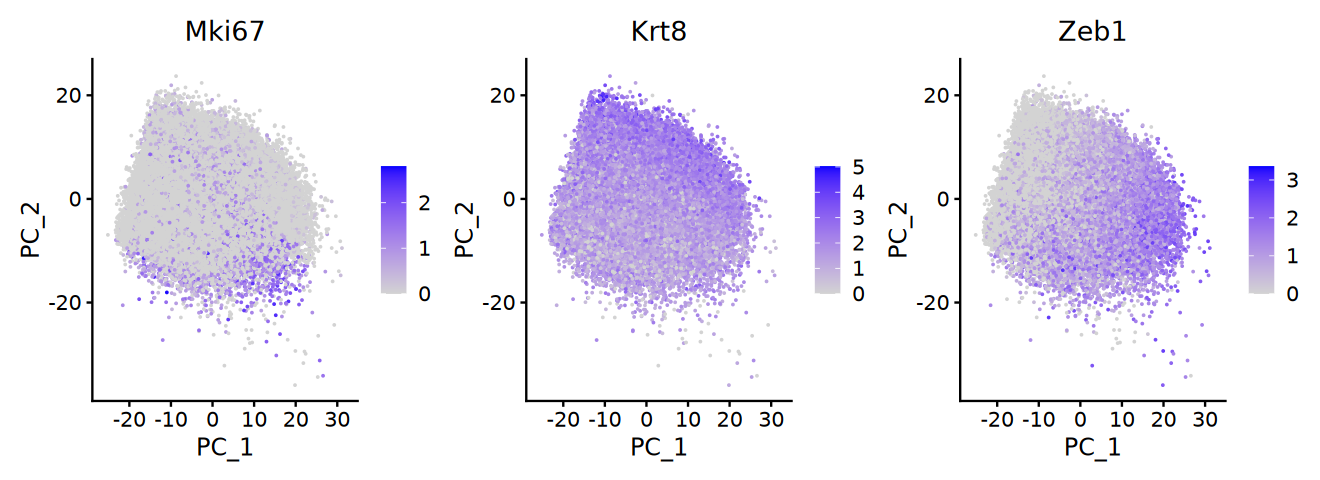

In [26]:
options(repr.plot.width=11, repr.plot.height=4)
FeaturePlot(sc.all.merge,features = c('Mki67','Krt8','Zeb1'),ncol = 3)

In [27]:
sc.all.merge <- RunUMAP(sc.all.merge, dims = 1:30)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:15:56 UMAP embedding parameters a = 0.9922 b = 1.112

10:15:56 Read 92018 rows and found 30 numeric columns

10:15:56 Using Annoy for neighbor search, n_neighbors = 30

10:15:56 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:16:05 Writing NN index file to temp file /tmp/Rtmp61vm97/file2a46167f635e4

10:16:05 Searching Annoy index using 1 thread, search_k = 3000

10:16:42 Annoy recall = 100%

10:16:45 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors

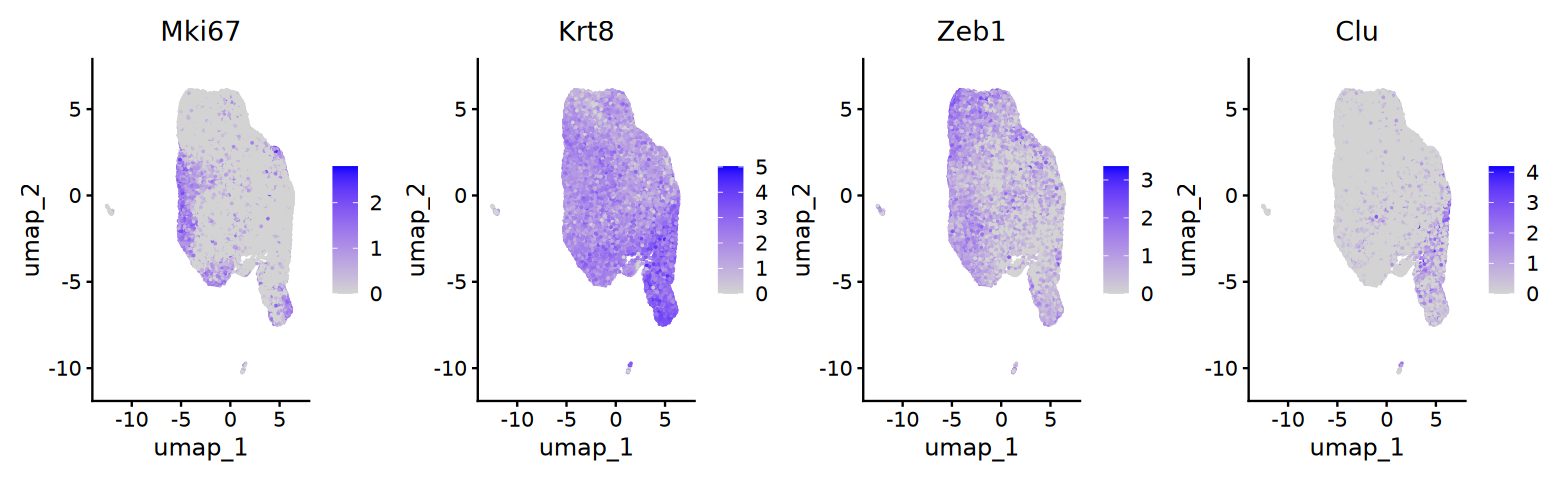

In [29]:
options(repr.plot.width=13, repr.plot.height=4)
FeaturePlot(sc.all.merge,features = c('Mki67','Krt8','Zeb1','Clu'),ncol = 4)

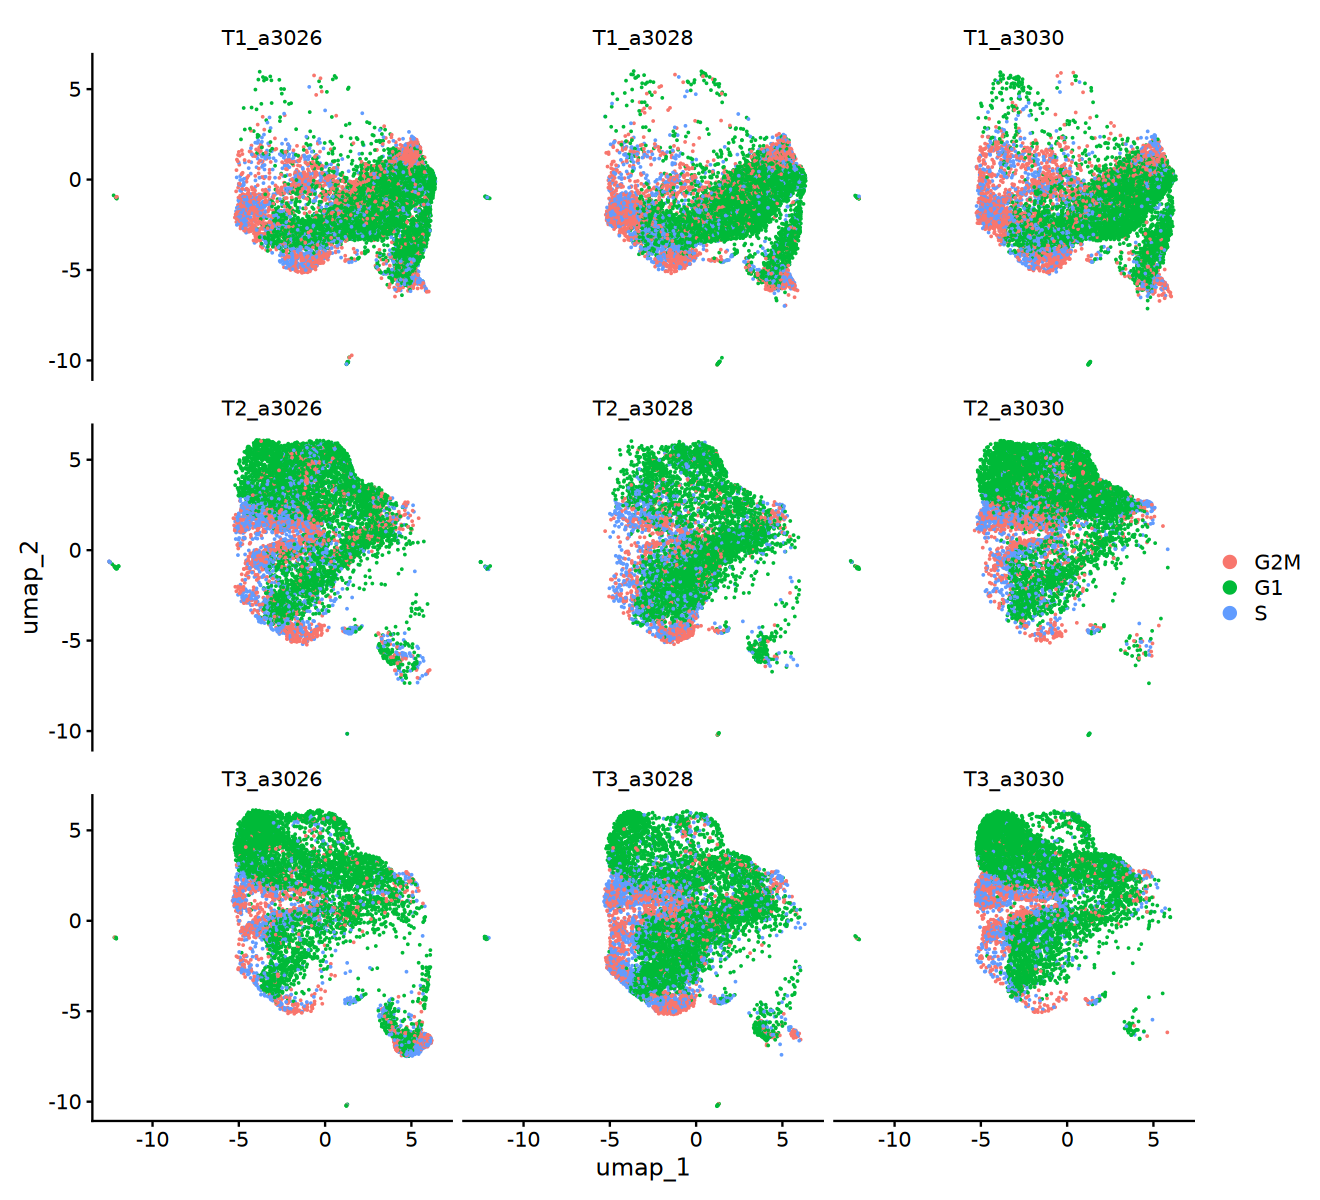

In [33]:
options(repr.plot.width=11, repr.plot.height=10)
DimPlot(sc.all.merge,split.by = 'orig.ident',ncol=3)

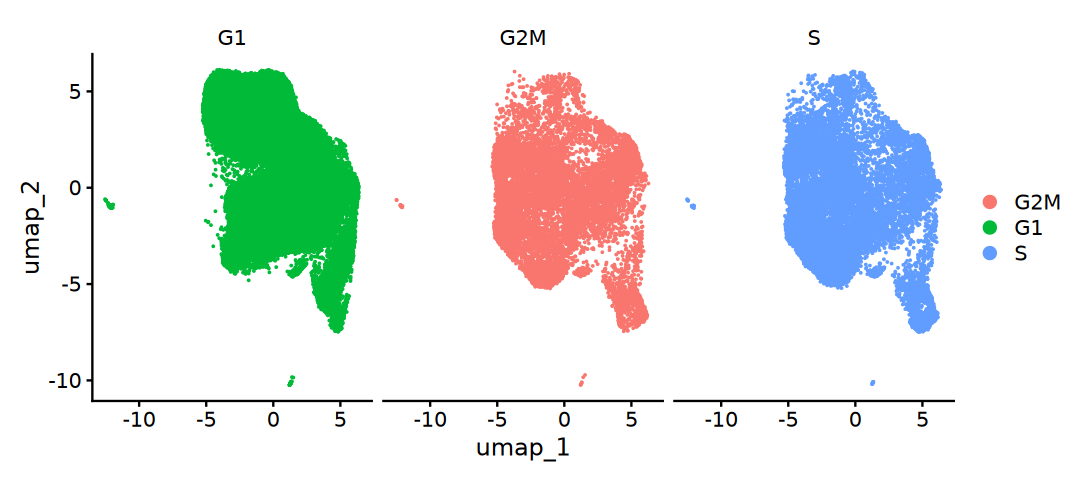

In [35]:
options(repr.plot.width=9, repr.plot.height=4)
DimPlot(sc.all.merge,split.by = 'Phase')

In [36]:
sc.all.merge <- IntegrateLayers(object = sc.all.merge, method = HarmonyIntegration,orig.reduction = "pca",new.reduction = "harmony",verbose = F)

Warning message:
“HarmonyMatrix is deprecated and will be removed in the future from the API in the future”
Warning message:
“Warning: The parameters do_pca and npcs are deprecated. They will be ignored for this function call and please remove parameters do_pca and npcs and pass to harmony cell_embeddings directly.
This warning is displayed once per session.”
Warning message:
“Warning: The parameter tau is deprecated. It will be ignored for this function call and please remove parameter tau in future function calls. Advanced users can set value of parameter tau by using parameter .options and function harmony_options().
This warning is displayed once per session.”
Warning message:
“Warning: The parameter block.size is deprecated. It will be ignored for this function call and please remove parameter block.size in future function calls. Advanced users can set value of parameter block.size by using parameter .options and function harmony_options().
This warning is displayed once per sessi

In [37]:
sc.all.merge <- RunUMAP(sc.all.merge, dims = 1:30,reduction= "harmony",reduction.name = "umap.harmony" )

10:33:00 UMAP embedding parameters a = 0.9922 b = 1.112

10:33:00 Read 92018 rows and found 30 numeric columns

10:33:00 Using Annoy for neighbor search, n_neighbors = 30

10:33:00 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:33:10 Writing NN index file to temp file /tmp/Rtmp61vm97/file2a4617d1b7517

10:33:10 Searching Annoy index using 1 thread, search_k = 3000

10:34:13 Annoy recall = 100%

10:34:13 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:34:17 Initializing from normalized Laplacian + noise (using RSpectra)

10:34:21 Commencing optimization for 200 epochs, with 4158682 positive edges

10:36:29 Optimization finished



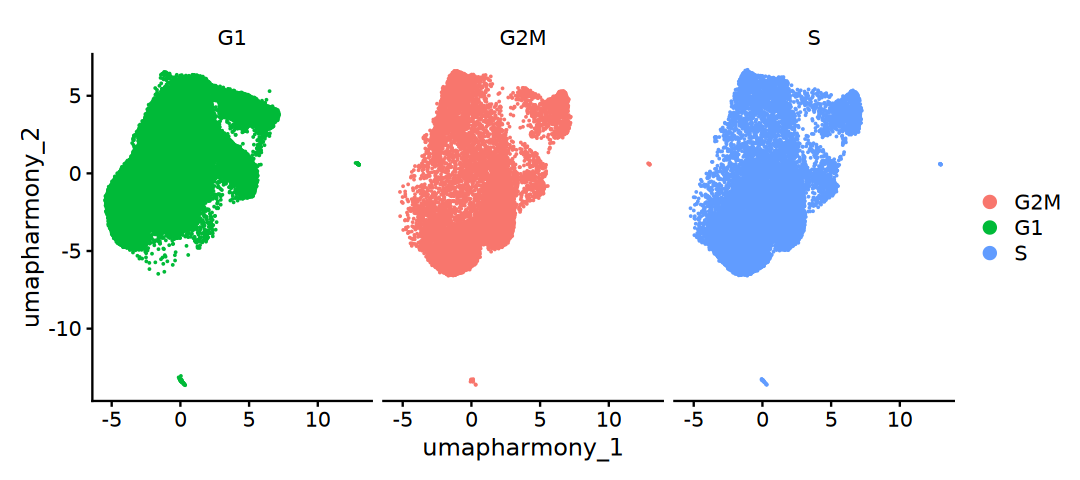

In [40]:
options(repr.plot.width=9, repr.plot.height=4)
DimPlot(sc.all.merge,split.by = 'Phase',reduction = "umap.harmony")

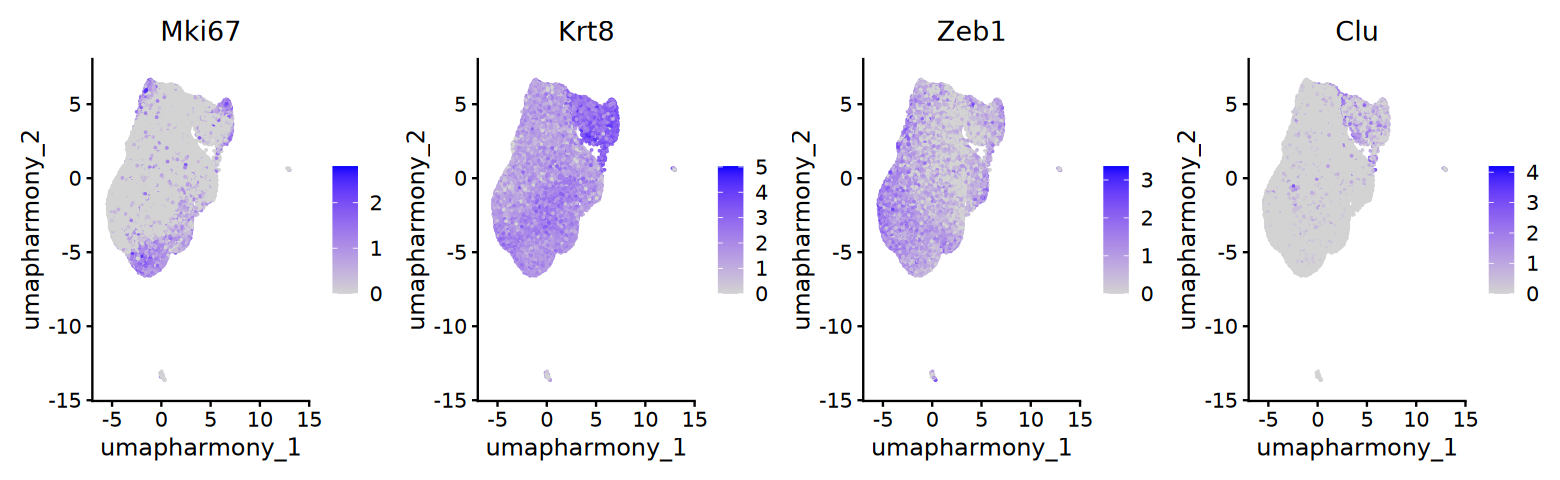

In [41]:
options(repr.plot.width=13, repr.plot.height=4)
FeaturePlot(sc.all.merge,features = c('Mki67','Krt8','Zeb1','Clu'),ncol = 4,reduction = "umap.harmony")

In [42]:
sc.all.merge <- FindNeighbors(sc.all.merge, reduction = "harmony", dims = 1:30)

Computing nearest neighbor graph

Computing SNN



In [45]:
sc.all.merge <- FindClusters(sc.all.merge, resolution = 0.1, cluster.name = "harmony_clusters")

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 92018
Number of edges: 2424990

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9313
Number of communities: 10
Elapsed time: 42 seconds


3 singletons identified. 7 final clusters.



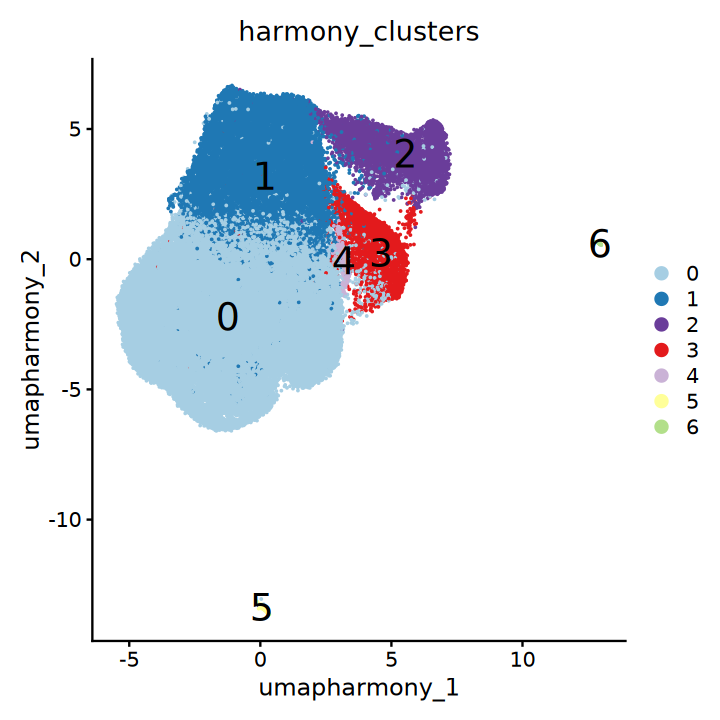

In [46]:
options(repr.plot.width = 6, repr.plot.height = 6) 
DimPlot(sc.all.merge, reduction = "umap.harmony",label.size = 8,raster=FALSE,label = T,group.by = 'harmony_clusters',
       cols = c('#a6cee3','#1f78b4','#6a3d9a','#e31a1c','#cab2d6','#ffff99','#b2df8a','#fdbf6f','#ff7f00','#fb9a99','#33a02c','#b15928'))

In [50]:
table(sc.all.merge@meta.data$harmony_clusters)


    0     1     2     3     4     5     6 
51570 28804  6434  4607   332   192    79 

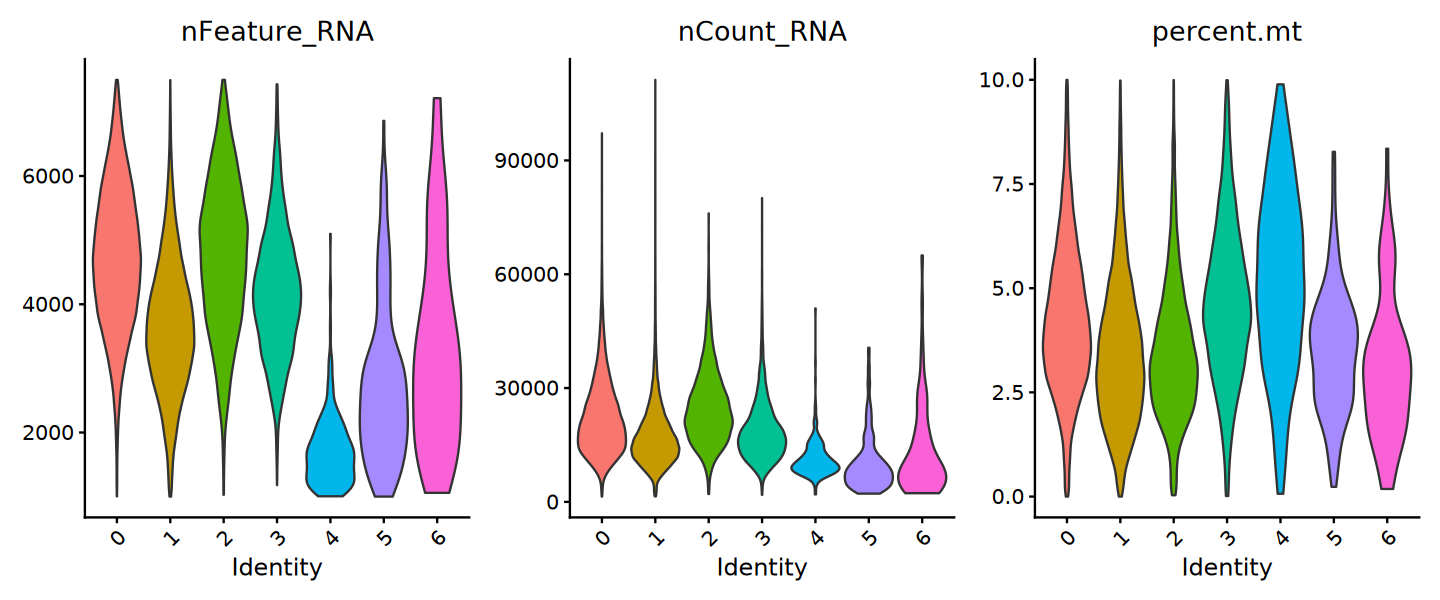

In [51]:
options(repr.plot.width = 12, repr.plot.height = 5) 
VlnPlot(sc.all.merge, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3,pt.size=0,group.by = 'harmony_clusters')

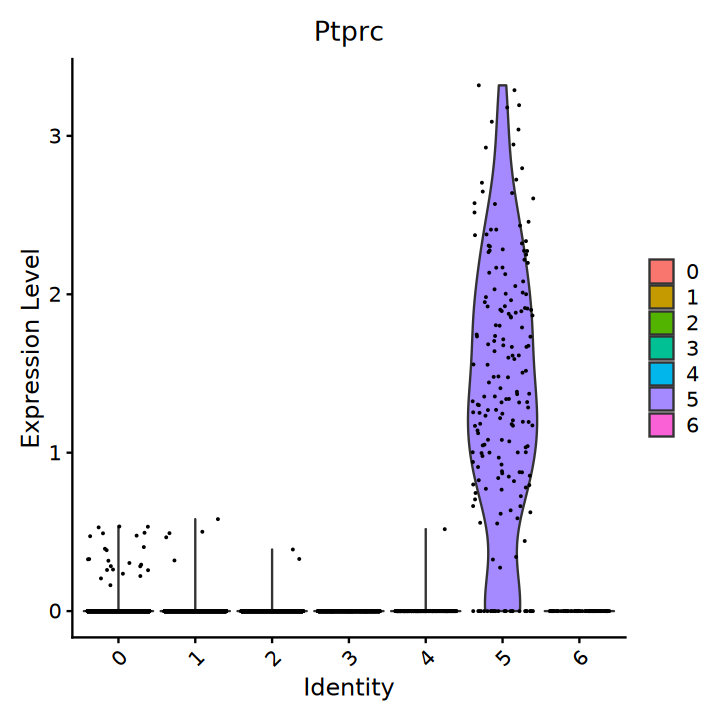

In [53]:
options(repr.plot.width = 6, repr.plot.height = 6) 
VlnPlot(sc.all.merge,features = 'Ptprc',group.by = 'harmony_clusters')

In [54]:
sc.all.merge

An object of class Seurat 
32285 features across 92018 samples within 1 assay 
Active assay: RNA (32285 features, 2000 variable features)
 19 layers present: counts.T1_a3026, counts.T1_a3028, counts.T1_a3030, counts.T2_a3026, counts.T2_a3028, counts.T2_a3030, counts.T3_a3026, counts.T3_a3028, counts.T3_a3030, scale.data, data.T1_a3026, data.T1_a3028, data.T1_a3030, data.T2_a3026, data.T2_a3028, data.T2_a3030, data.T3_a3026, data.T3_a3028, data.T3_a3030
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

In [55]:
saveRDS(sc.all.merge,file='/syn1/liangzhen/jinhua_jilab_project/result/scRNA/cellranger/sc.mtx.cellCycle.removal.rds')

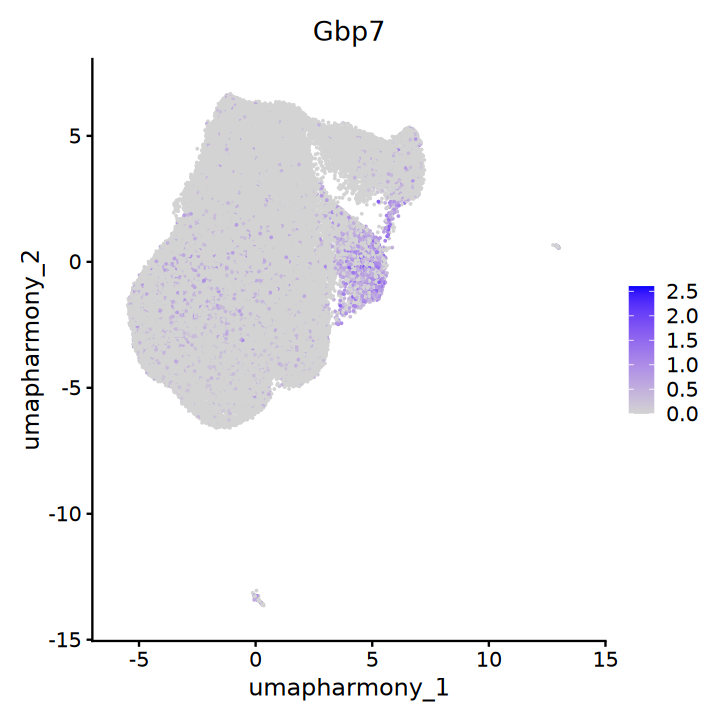

In [47]:
options(repr.plot.width = 6, repr.plot.height = 6) 
FeaturePlot(sc.all.merge,features = 'Gbp7',reduction = "umap.harmony")

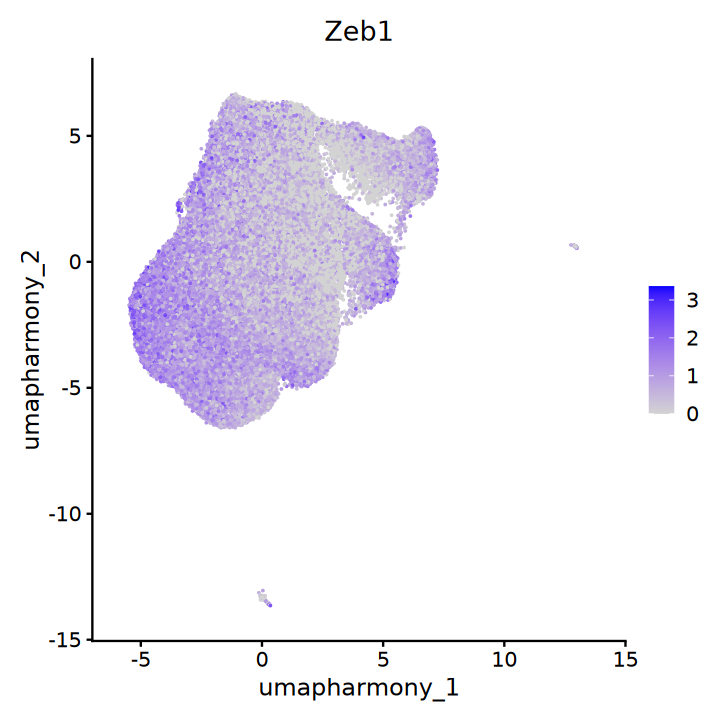

In [48]:
options(repr.plot.width = 6, repr.plot.height = 6) 
FeaturePlot(sc.all.merge,features = 'Zeb1',reduction = "umap.harmony")

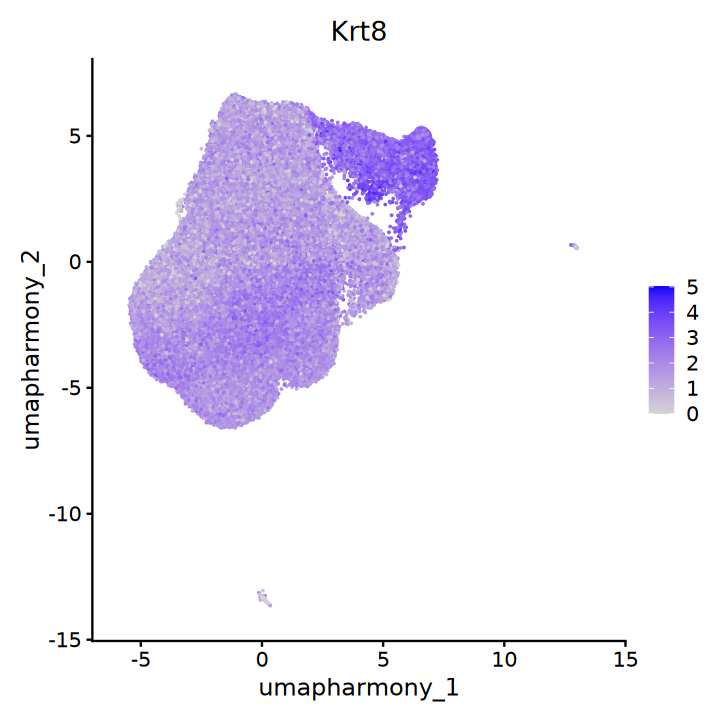

In [49]:
options(repr.plot.width = 6, repr.plot.height = 6) 
FeaturePlot(sc.all.merge,features = 'Krt8',reduction = "umap.harmony")

In [56]:
library(ggplot2)
options(repr.plot.width = 15, repr.plot.height = 5)
sc.all.merge@meta.data$Num <- 1
plot <- ggplot(data=sc.all.merge@meta.data,aes(orig.ident,Num,fill=harmony_clusters)) + geom_bar(stat="identity",position="fill",width=0.8) +
    xlab('') + ylab('Ratio of clusters')+ labs(fill='cluster')+
    scale_fill_manual(values = c('#a6cee3','#54278f','#e7298a','#1f77b4','#ff6600'))+
    theme_bw() + theme(panel.grid=element_blank(),
                  axis.text = element_text(size=15,angle = 90,hjust = 1,vjust = 0.5),axis.title = element_text(size=15),
                  legend.text=element_text(size=15),legend.title=element_text(size=15))
plot

ERROR while rich displaying an object: Error in `palette()`:
! Insufficient values in manual scale. 7 needed but only 5 provided.

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2repr[[mime]](obj)
7. repr_text.defau

In [ ]:
sc.all.merge <- JoinLayers(sc.all.merge)

In [ ]:
Idents(sc.all.merge) <- sc.all.merge@meta.data$harmony_clusters

sc.all.merge.markers <- FindAllMarkers(sc.all.merge, only.pos = TRUE,min.pct = 0.1)

In [ ]:
sc.all.merge.markers.filter <- sc.all.merge.markers[sc.all.merge.markers$avg_log2FC>1 & sc.all.merge.markers$p_val_adj < 0.05,]
sc.all.merge.markers.filter

# pseudotime

In [34]:
library(monocle3)
library(ggplot2)
library(dplyr)
library(Seurat)

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: SingleCellExperiment

Loading required pac

In [29]:
sc.all.merge <- JoinLayers(sc.all.merge)

In [30]:
gene_metadata <- data.frame(gene_short_name=rownames(sc.all.merge),row.names=rownames(sc.all.merge))
cell_metadata <- sc.all.merge@meta.data

In [31]:
cds <- monocle3::new_cell_data_set(sc.all.merge@assays$RNA@layers$counts,cell_metadata = cell_metadata,gene_metadata = gene_metadata)

In [32]:
cds <- monocle3::preprocess_cds(cds, num_dim = 30)

In [35]:
reducedDims(cds)[["UMAP"]] <- sc.all.merge@reductions$umap.harmony@cell.embeddings

In [36]:
cds <- monocle3::cluster_cells(cds,k=30)

In [37]:
cds <- monocle3::learn_graph(cds)

  |======================================================================| 100%


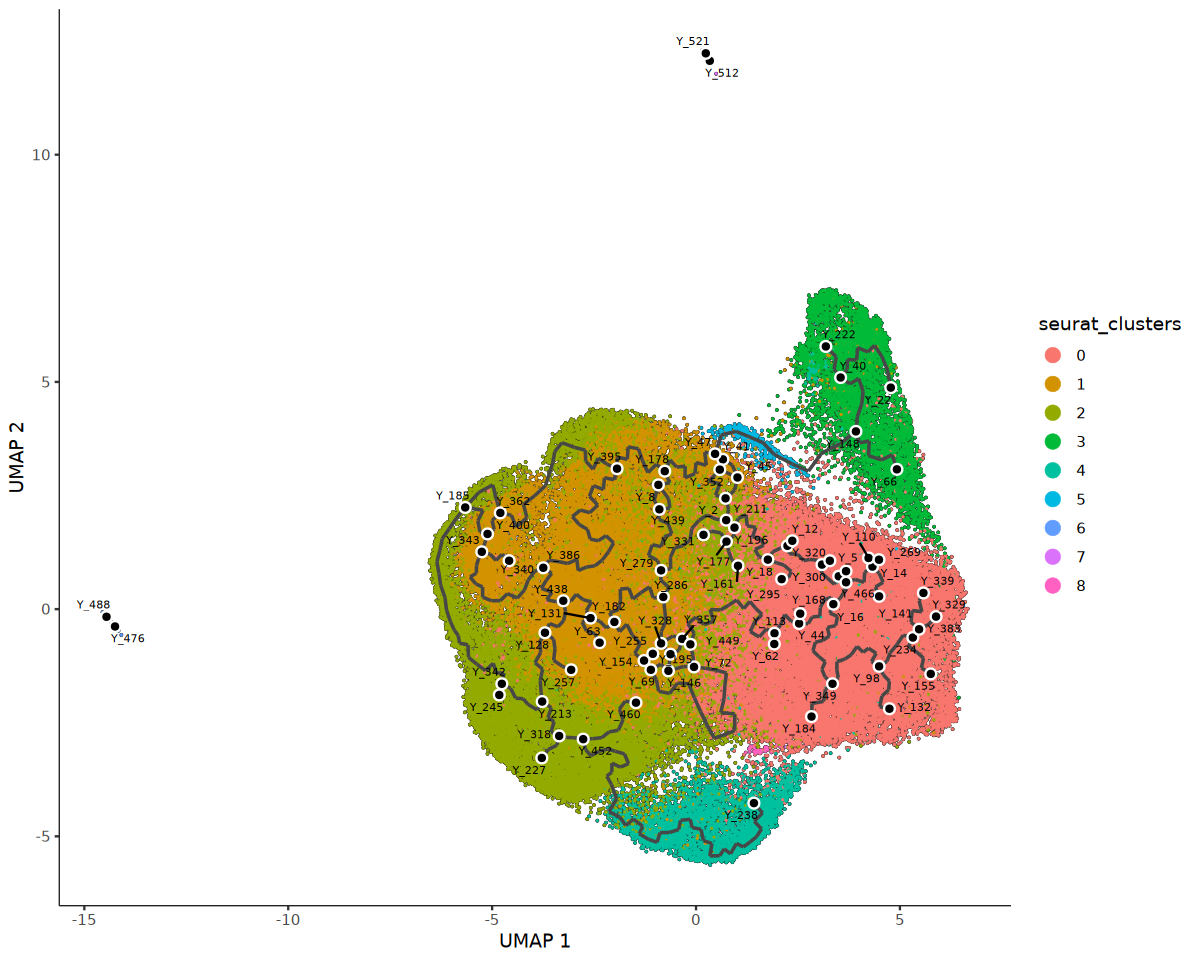

In [38]:
options(repr.plot.width = 10, repr.plot.height = 8)
monocle3::plot_cells(cds,
           color_cells_by = "seurat_clusters",
           label_cell_groups=FALSE,
           label_leaves=FALSE,
           label_branch_points=FALSE,
           label_principal_points = TRUE,
           graph_label_size=1.5)

In [39]:
cds <- monocle3::order_cells(cds, root_pr_nodes='Y_222')

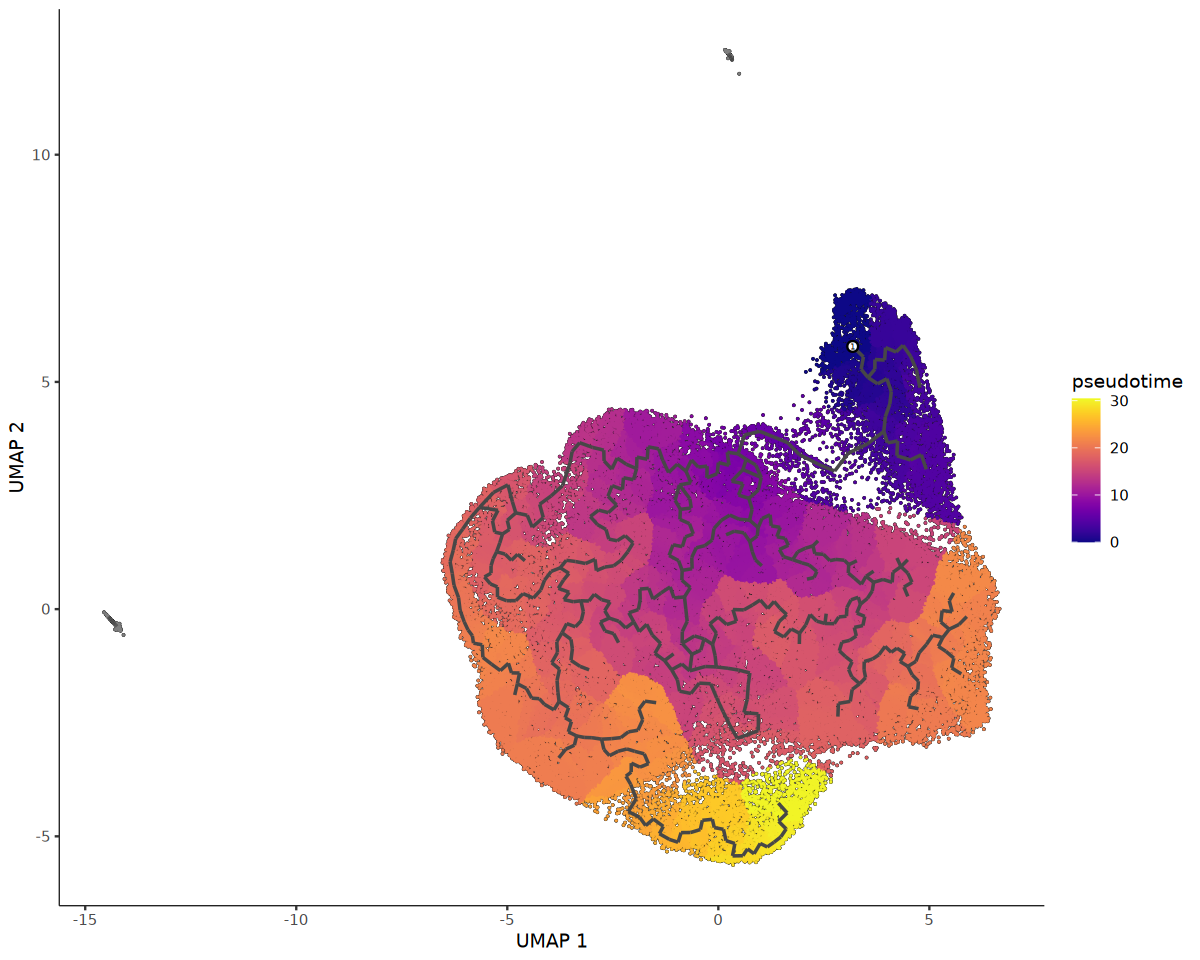

In [40]:
options(repr.plot.width = 10, repr.plot.height = 8)
plot_cells(cds,
           color_cells_by = "pseudotime",
           label_cell_groups=FALSE,
           label_leaves=FALSE,
           label_branch_points=FALSE,
           graph_label_size=1.5)

In [41]:
AFD_genes <- c("Krt8", "Zeb1", "Cdh1",'Cdh2')
AFD_lineage_cds <- cds[rowData(cds)$gene_short_name %in% AFD_genes,]
#AFD_lineage_cds <- order_cells(AFD_lineage_cds)

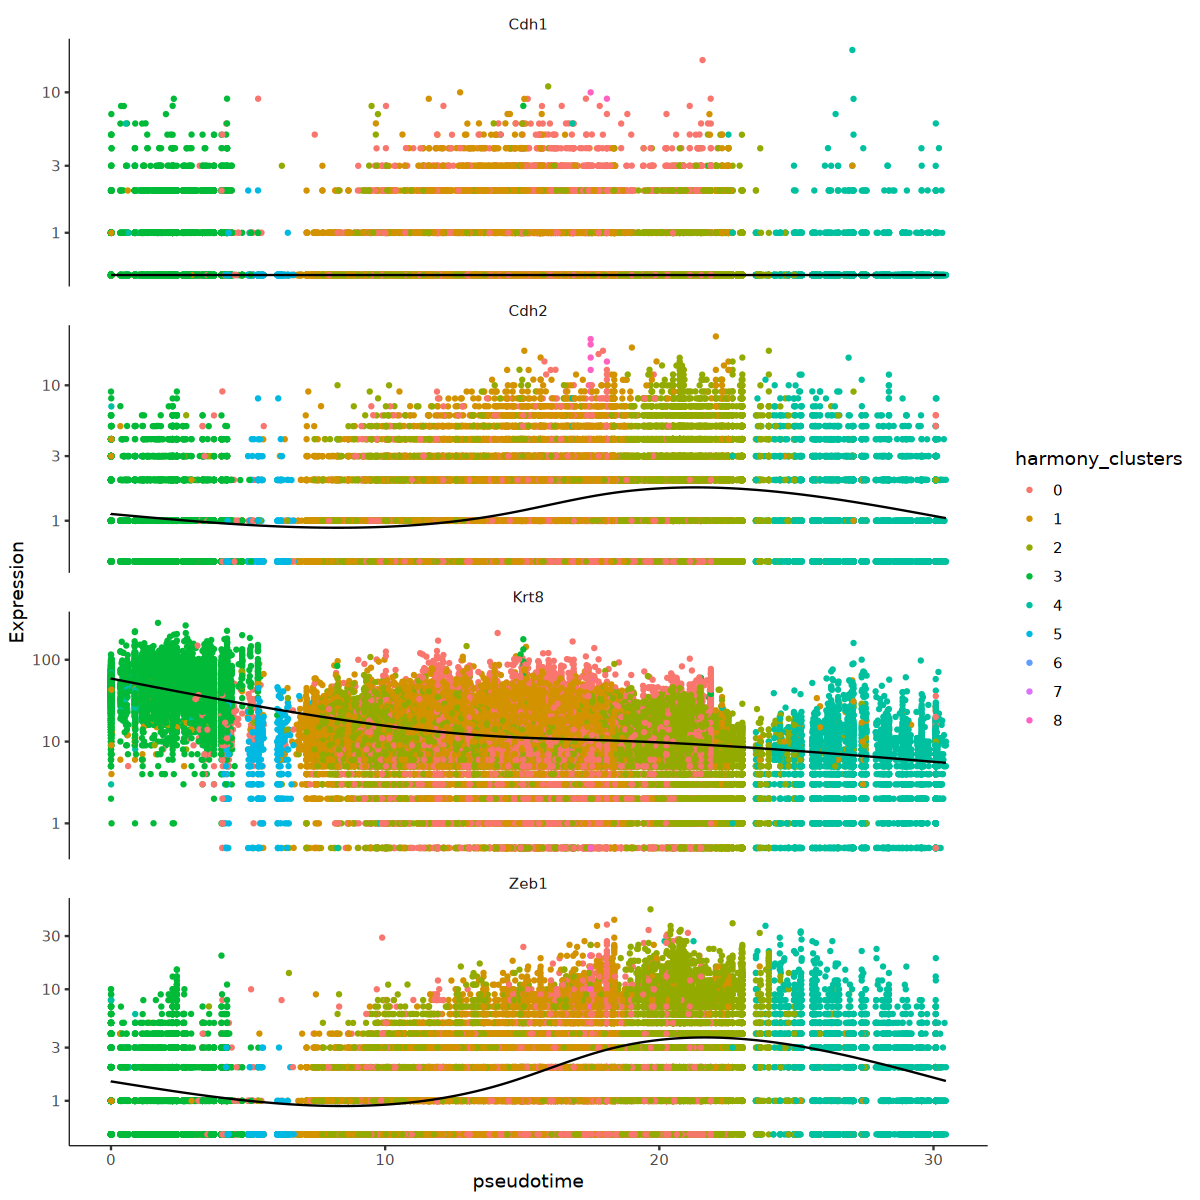

In [43]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot_genes_in_pseudotime(AFD_lineage_cds,
                         color_cells_by = "harmony_clusters",
                         min_expr=0.5)